# Things we need to work on

1.   Setup the gym and explore the parameters - DONE
2.   Setup the neural network model to be used for trainer and student network - DONE
3. Define neural network hyper parameters and other essential datastructures - DONE




In [ ]:
import gymnasium as gym

env = gym.make("CartPole-v1")
#env.observation_space.n, env.action_space.n
action_size = env.action_space.n # 2 (left, right)
print("Action size: ", action_size)
#print(env.observation_space)
#print(env.observation_space.shape)
state_size = env.observation_space.shape[0] # 4 (cart position, cart velocity, pole angle, pole angular velocity)
print("State size: ", state_size)


print("Do a random sample of an action space: ", env.action_space.sample())

state, info = env.reset()
print("Current state: ", state)
state, reward, terminated, truncated, _ = env.step(0) # make it go left
print(f"Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [{state, reward, terminated, truncated}]")
state, reward, terminated, truncated, _ = env.step(1) # make it go right
print(f"Make it go right (env.step(1) - [State, Reward, Is Terminated?, Is Truncated?]] - [{state, reward, terminated, truncated}]")
state, reward, terminated, truncated, _ = env.step(0) # make it go left
print(f"Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [{state, reward, terminated, truncated}]")

Action size:  2
State size:  4
Do a random sample of an action space:  0
Current state:  [-0.01850153 -0.04454422  0.01436551  0.03543375]
Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [(array([-0.01939242, -0.23986919,  0.01507419,  0.3326143 ], dtype=float32), 1.0, False, False)]
Make it go right (env.step(1) - [State, Reward, Is Terminated?, Is Truncated?]] - [(array([-0.0241898 , -0.04496501,  0.02172648,  0.04472288], dtype=float32), 1.0, False, False)]
Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [(array([-0.0250891 , -0.24039166,  0.02262093,  0.34418076], dtype=float32), 1.0, False, False)]


In [ ]:
import torch
import torch.nn as nn

class DQN(nn.Module):
	def __init__(self, state_size, action_size):
		super(DQN, self).__init__()
		self.l1 = nn.Linear(state_size, 64)
		self.l2 = nn.Linear(64, 64)
		self.l3 = nn.Linear(64, action_size)

	def forward(self, x):
		x = torch.relu(self.l1(x))
		x = torch.relu(self.l2(x))
		x = self.l3(x)
		return x

In [ ]:
from collections import deque

#HYPERPARAMETERS
MIN_EPSILON = 1e-2 # define when the agent do exploration
MAX_EPSILON = 1.0
EPSILON = 1.0
DECAY_RATE = 0.005
GAMMA = 0.99 # how much the agent should go for future rewards?
LEARNING_RATE = 1e-4
MAX_ITERATIONS = 500
BATCH_SIZE = 128
MAX_MEMORY_BANK_SIZE = 50000
MAX_EPISODES = 1000
DECAY_STEPS = 10000
TAU = 0.005

device = 'cpu'
if torch.cuda.is_available():
  device = 'cuda'

print(f"Using device {device}")
# DEFINE NETWORKS
policy_net= DQN(state_size, action_size).to(device = device) # student network
target_net = DQN(state_size, action_size).to(device = device) # trainer network

target_net.load_state_dict(policy_net.state_dict()) # setup the target_network with same weights as the policy network

optimizer = torch.optim.AdamW(policy_net.parameters(), LEARNING_RATE)

memory= deque(maxlen=MAX_MEMORY_BANK_SIZE)


Using device cuda


In [ ]:
state, _ = env.reset()
print("State: ", state)
state_tensor = torch.tensor(state, dtype = torch.float32).view(1, state_size).to(device)
print("state_tensor.shape ", state_tensor.shape)
q_value = policy_net(state_tensor)
print("q_value.shape: ", q_value.shape)
print("q_value: ", q_value)
print(q_value.max(1)[0])

State:  [-0.00426479 -0.00052945  0.01407855  0.01114365]
state_tensor.shape  torch.Size([1, 4])
q_value.shape:  torch.Size([1, 2])
q_value:  tensor([[-0.0515,  0.1740]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([0.1740], device='cuda:0', grad_fn=<MaxBackward0>)


Training for the agent has started
Episode 100 is finished and total reward is 33.0, and epsilon (exploration) is 0.9988853929203075
Episode 200 is finished and total reward is 23.0, and epsilon (exploration) is 0.9978411872014861
Episode 300 is finished and total reward is 13.0, and epsilon (exploration) is 0.9967487454327164
Episode 400 is finished and total reward is 18.0, and epsilon (exploration) is 0.9955520520706836
Episode 500 is finished and total reward is 21.0, and epsilon (exploration) is 0.9944183342385252
Episode 600 is finished and total reward is 10.0, and epsilon (exploration) is 0.9933827789982796
Episode 700 is finished and total reward is 19.0, and epsilon (exploration) is 0.9922171783601934
Episode 800 is finished and total reward is 18.0, and epsilon (exploration) is 0.991127031599645
Episode 900 is finished and total reward is 21.0, and epsilon (exploration) is 0.9899660646223072
Episode 1000 is finished and total reward is 26.0, and epsilon (exploration) is 0.98

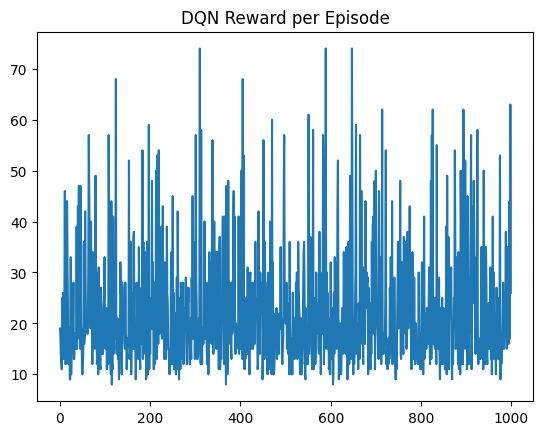

In [ ]:
import random
import numpy as np
import time
import torch.nn.functional as F
import matplotlib.pyplot as plt


def get_next_action(current_state, epsilon):
  if random.uniform(0, 1) < epsilon:
    action = env.action_space.sample()
    return torch.tensor(action, dtype = torch.long, device = device).view(1, 1)
  else:
    with torch.no_grad():
      q_value = policy_net(current_state)
      return q_value.max(1)[1].view(1, 1)

print("Training for the agent has started")
steps_done = 0
start_time = time.time()
episode_rewards = []
epsilon = EPSILON
for eps in range(1, MAX_EPISODES + 1):
  state, _ = env.reset()
  state = torch.tensor(state, dtype = torch.float32, device = device).view(1, state_size)
  total_reward = 0
  for step in range(1, MAX_ITERATIONS + 1):
    action = get_next_action(state, epsilon)
    next_state, reward, is_terminated, is_truncated, _ = env.step(action.item())
    total_reward += reward
    reward = torch.tensor([reward], device = device)
    done = is_terminated or is_truncated
    next_state = torch.tensor([next_state], device=device)
    steps_done += 1
    if done:
      next_state = None
    memory.append((state, action, next_state, reward, torch.tensor([done], dtype = torch.float32, device = device)))
    state = next_state
    if len(memory) > BATCH_SIZE:
      transitions = random.sample(memory, BATCH_SIZE)
      batch_state, batch_action, batch_next_state, batch_reward, batch_done = zip(*transitions)
      b_s = torch.cat(batch_state) # (64,4)
      b_a = torch.cat(batch_action) # (64, 2)
      b_r = torch.cat(batch_reward) # (64, 1)
      b_d = torch.cat(batch_done) # (64, 1)
      current_q = policy_net(b_s).gather(1, b_a) # (64,2) -> (64, 1)
      with torch.no_grad():
        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch_next_state)), dtype = torch.bool, device = device)
        non_final_next_states = torch.cat([s for s in batch_next_state if s is not None]).to(device)
        # bellman equation
        next_q = torch.zeros(BATCH_SIZE, device=device)
        next_q[non_final_mask] = target_net(non_final_next_states).max(1)[0] # max over dim 1 and get the value
        #print("b_r.shape: ", b_r.shape)
        target_q = GAMMA * next_q.unsqueeze(1) + b_r.unsqueeze(1)
      #print("current_q.shape: ", current_q.shape)
      #print("target_q.shape: ", target_q.shape)
      loss = F.smooth_l1_loss(current_q, target_q)
      optimizer.zero_grad()
      loss.backward()
      torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
      optimizer.step()
      epsilon = MIN_EPSILON + (MAX_EPSILON - MIN_EPSILON) * np.exp(-DECAY_RATE * (steps_done / DECAY_STEPS))
      target_net_state_dict = target_net.state_dict()
      policy_net_state_dict = policy_net.state_dict()
      for key in policy_net_state_dict:
        target_net_state_dict[key] = TAU * policy_net_state_dict[key] + (1 - TAU) * target_net_state_dict[key]
      target_net.load_state_dict(target_net_state_dict)
    if done:
      break
  if eps % 100 == 0:
    print(f"Episode {eps} is finished and total reward is {total_reward}, and epsilon (exploration) is {epsilon}")
  episode_rewards.append(total_reward)
print("Training for the agent has completed")
end_time = time.time()
print("Elapsed time: ", (end_time - start_time), "s")
plt.plot(episode_rewards); plt.title("DQN Reward per Episode"); plt.show()

Starting testing for 10 episodes...
Test Episode 1: Reward = 115.0
Test Episode 2: Reward = 183.0
Test Episode 3: Reward = 191.0
Test Episode 4: Reward = 123.0
Test Episode 5: Reward = 163.0
Test Episode 6: Reward = 166.0
Test Episode 7: Reward = 141.0
Test Episode 8: Reward = 266.0
Test Episode 9: Reward = 278.0
Test Episode 10: Reward = 160.0

Average Test Reward: 178.6


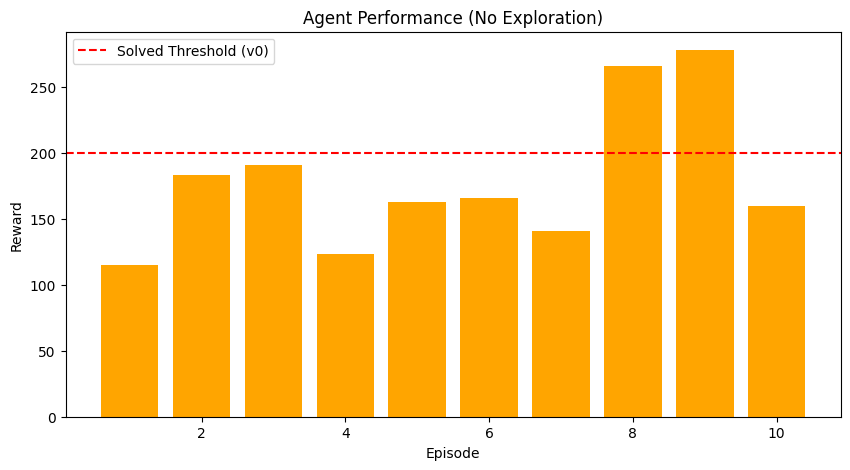

In [ ]:
def test_agent(num_episodes=10, render=False):
    # If using a local machine, you can change to "human" to watch it
    env_test = gym.make("CartPole-v1", render_mode="human" if render else None)
    test_rewards = []
    print(f"Starting testing for {num_episodes} episodes...")

    policy_net.eval() # Set network to evaluation mode

    for eps in range(num_episodes):
        state, _ = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device = device).unsqueeze(0)
        total_reward = 0
        done = False

        while not done:
            with torch.no_grad():
                # Always take the best action (Exploitation)
                action = policy_net(state).max(1)[1].view(1, 1)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            total_reward += reward
            done = terminated or truncated

            state = torch.tensor(next_state, dtype=torch.float32, device = device).unsqueeze(0)

        test_rewards.append(total_reward)
        print(f"Test Episode {eps+1}: Reward = {total_reward}")

    print(f"\nAverage Test Reward: {np.mean(test_rewards)}")

    # Plotting the test results
    plt.figure(figsize=(10,5))
    plt.bar(range(1, num_episodes + 1), test_rewards, color='orange')
    plt.axhline(y=200, color='r', linestyle='--', label='Solved Threshold (v0)')
    plt.title("Agent Performance (No Exploration)")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.show()

# Run the test
test_agent(num_episodes=10)

In [ ]:
# trick in tuple
mem = deque(maxlen = 1000)
mem.append((1,2,3,4))
mem.append((5,6,7,8))
sample = random.sample(mem, 2)
print(sample)
a, b, c, d = zip(*sample)
print(a)
print(b)
print(c)
print(d)

[(1, 2, 3, 4), (5, 6, 7, 8)]
(1, 5)
(2, 6)
(3, 7)
(4, 8)


Starting testing for 10 episodes...
Test Episode 1: Reward = 115.0
Test Episode 2: Reward = 172.0
Test Episode 3: Reward = 150.0
Test Episode 4: Reward = 174.0
Test Episode 5: Reward = 126.0
Test Episode 6: Reward = 111.0
Test Episode 7: Reward = 112.0
Test Episode 8: Reward = 162.0
Test Episode 9: Reward = 103.0
Test Episode 10: Reward = 119.0

Average Test Reward: 134.4


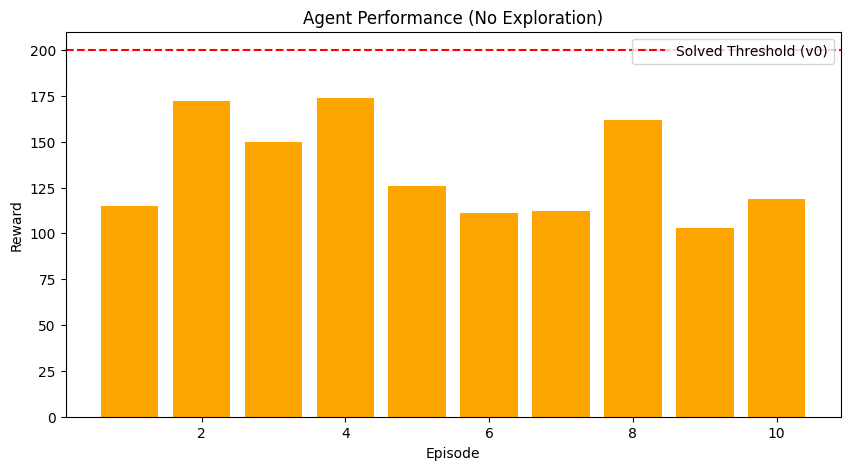

In [ ]:
%matplotlib inline
test_agent(num_episodes=10, render = False)

In [ ]:
PATH = 'cart-pole-v1-model_parameters.pth'
torch.save(policy_net.state_dict(), PATH)